# Latent Space Sensitivity

- This notebook reproduces the following upstream-related figures in Guo et al. (2026).
    - Fig. R1 in the 2nd round review
- **Additional data reminder**:
    - Pre-calculated data have been saved in `/data/processed/demo_data`, so figures in this notebook can be reproduced without additional datasets.
- Execution order of cell sections for reproducing figures: 
    1. `Import`
    2. `Utilities`
    3. Each `Figure: ...`

# Import

- This notebook reproduces the following upstream-related figures in Guo et al. (2026).
    - Fig. 4(c)(d)
    - Fig. 6(a)(d)
    - Fig. 7(d)–(g)
    - Fig. 9(a)
    - Supplementary figures S11
- **Additional data reminder**:
    - Pre-calculated data have been saved in `/data/processed/demo_data`, so figures in this notebook can be reproduced without additional datasets.
    - If desired, pre-calculated data can be reproduced using:
        - TaiESM1 IVT (historical and ssp585): to be downloaded from Zenodo (doi:10.5281/zenodo.17199183)
        - TaiESM1 U, V, Q (historical)
        - ERA5 (2001–2019): to be downloaded from (https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=download)
- Execution order of cell sections for reproducing figures: 
    1. `Import`
    2. `Utilities`
    3. Each `Figure: ...`

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import glob
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmaps
import seaborn.colors.xkcd_rgb as c
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

In [51]:
# --- self define modules --- #
import importlib
import sys
sys.path.append('../../src/main/')
import util_draw_polar
importlib.reload(util_draw_polar);

# Utilities

## Data

In [4]:
df_up_polar = pd.read_csv('../../data/processed/weather_table_self/all_polar.csv')      # weather table w/ upstream IVT info.
wtab_all    = pd.read_csv('../../data/processed/weather_table_self/all_withlv.csv')     # weather table
swpcp_all   = pd.read_csv('../../data/processed/weather_table_self/swland_pcp_all.csv') # southwestern Taiwan rainfall
twpcp_all   = pd.read_csv('../../data/processed/weather_table_self/taiwan_pcp_all.csv') # Taiwan rainfall
swpcp_ratio = ((swpcp_all['accu'])/(twpcp_all['accu']))

In [5]:
topo_fpath = '../../data/raw/vvm_TOPO.nc'   # high-resolution (500m) Taiwan topography

## !!

In [47]:
pcp_fpath  = ''

In [48]:
LS_figpath = ''

In [49]:
polar_figpath = ''

In [50]:
obs_figpath   = ''

## General classes and functions

In [7]:
class weather_table():
    def __init__(self, year_list:list, month_list:list, 
                 special_start_date:str=False, special_end_date:str=False, 
                 lat_range=(None, None), lon_range=(None, None)):
        self.YEARS     = year_list
        self.MONTHS    = month_list
        self.STARTDATE = self._convert_to_dobj(special_start_date) if special_start_date else None
        self.ENDDATE   = self._convert_to_dobj(special_end_date) if special_end_date else None
        self.LATRANGE  = lat_range if lat_range[0]>lat_range[1] and \
                         lat_range[0] is not None and lat_range[1] is not None \
                         else lat_range[::-1]  # for ERA5 data
        self.LONRANGE  = lon_range
    
    def _convert_to_dobj(self, date):
        """
        Convert a date string into a datetime object.
        Two types of string format are supported: 20051218 or 2005-12-18.
        """
        if isinstance(date, str):
            if len(date)>8:
                dateobj = datetime.strptime(date, '%Y-%m-%d')
            else:
                dateobj = datetime.strptime(date, '%Y%m%d')
        else:
            dateobj = date
        return dateobj

    
    def get_cwb_precip_table(self, date:str, accumulate_daily=False):
        if not isinstance(date, str):
            date  = datetime.strftime(date, '%Y%m%d')
        # File list
        cwb_fpath = f'{pcp_fpath}/{date[:4]}/{date[4:6]}/{date}'
        cwb_flist = sorted(glob.glob(f'{cwb_fpath}/{date}*'))
        # Define column widths based on README
        col_widths = [7, 10, 9, 7, 7, 7, 7, 7, 7, 7, 7, 3]
        # Define the column names
        col_names = ['stno', 'lon', 'lat', 'elv', 'PS', 'T', 'RH',
                     'WS', 'WD', 'PP', 'odSS01', 'ojits']
        # Use read_fwf to read the fixed-width formatted file
        for hh in range(len(cwb_flist)):
            data = pd.read_fwf(cwb_flist[hh], widths=col_widths, names=col_names)
            cwb_lon, cwb_lat, cwb_pcp = data[['lon', 'lat', 'PP']].values.T
            self.cwb_LON = cwb_lon
            self.cwb_LAT = cwb_lat
            
            if accumulate_daily:                              # target_pcp is daily precip.
                if hh<1:
                    target_pcp = cwb_pcp
                else:
                    target_pcp = np.add(target_pcp, cwb_pcp)
                
            else:                                            # target_pcp is hourly precip.
                if hh<1:
                    target_pcp= cwb_pcp[np.newaxis, ...]
                else:
                    target_pcp= np.concatenate((target_pcp, cwb_pcp[np.newaxis, ...]), axis=0)
        target_pcp    = np.where(target_pcp>=0., target_pcp, np.nan)
        if accumulate_daily:
            pcp_table = pd.DataFrame({'stn_lon':cwb_lon, 'stn_lat':cwb_lat, 'precip':target_pcp})
        else:
            raise ValueError("Table for hourly precipitation isn't built yet.")
        return pcp_table
                
wtab_module_all  = weather_table(year_list=np.arange(2001, 2020).tolist(), month_list=np.arange(4, 10).tolist(), 
                                 lat_range=(22, 20), lon_range=(115, 119))

### Plot tools

In [8]:
class Plot_analysis():
    def __init__(self):
        self.proj = ccrs.PlateCarree()
        self.ds_topo = xr.open_dataset(topo_fpath)        
    
    def Axe_map(self, fig, gs, 
                xlim_, ylim_, **grid_info):
        # Set map extent
        axe  = fig.add_subplot(gs, projection=self.proj)
        axe.set_extent([xlim_[0], xlim_[-1], ylim_[0], ylim_[-1]], crs=self.proj)
        # Set additional grid information
        if len(grid_info)>0:
            if grid_info['xloc_'] is not None:
                axe.set_xticks(grid_info['xloc_'], crs=self.proj)
                axe.set_xticklabels(['' for i in range(len(grid_info['xloc_']))])  # default: no tick labels
            if grid_info['yloc_'] is not None:
                axe.set_yticks(grid_info['yloc_'], crs=self.proj)
                axe.set_yticklabels(['' for i in range(len(grid_info['yloc_']))])
            gl = axe.gridlines(xlocs=grid_info['xloc_'], ylocs=grid_info['yloc_'], 
                               draw_labels=False)
        return axe
    
    def Plot_cartopy_map(self, axe):
        axe.add_feature(cfeature.LAND,color='grey',alpha=0.1)
        axe.coastlines(resolution='50m', color='black', linewidth=1)
        return axe
    
    def Plot_vvm_map(self, axe, color, linewidth):
        axe.contour(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.topo, 
                    levels=np.array([-1e-3, 1e-3]), 
                    colors=color, linewidths=linewidth)
    
    def Plot_vvm_topo(self, axe, color, linewidth=None):
        topo_bounds= np.arange(0, 3500.1, 500)
        alpha_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
        cmap_topo  = colors.ListedColormap([(0, 0, 0, i) for i in alpha_list])
        norm_      = colors.BoundaryNorm(topo_bounds, cmap_topo.N, extend='max')
        imtopoh    = axe.contourf(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.height*1e3, 
                                  levels=topo_bounds, 
                                  cmap=cmap_topo, norm=norm_, extend='max', antialiased=1)
        if linewidth is not None:
            axe.contour(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.height*1e3, levels=np.array([499.99, 500.01]), 
                        colors=color, linewidths=linewidth)
        else:
            pass
        return imtopoh
        
    def Plot_twcwb_pcp(self, axe, 
                       lon, lat, precip,
                       s, alpha, precip_bounds=[1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300], edgecolors=None):
        bounds= np.array(precip_bounds)
        cmap  = cmaps.WhiteBlueGreenYellowRed
        norm  = colors.BoundaryNorm(bounds, cmap.N, extend='both')
        im    = axe.scatter(lon, lat, c=precip, s=s, 
                            cmap=cmap, norm=norm, alpha=alpha, edgecolors=edgecolors)
        return im
    
plottools = Plot_analysis()

In [9]:
def Plot_scatter(axe, x_, y_, c_=None, color_=None, 
                 s_=None, alpha_=None, label_=None, 
                 cmap_=None, bounds_=None, norm_=None, extend_='neither'):
    """
    Create scatter plot with some personal settings.
    """
    if bounds_ is not None:
        norm_    = colors.BoundaryNorm(bounds_, cmap_.N, extend=extend_)
    im = axe.scatter(x_, y_, c=c_, color=color_, s=s_, alpha=alpha_, 
                     label=label_, cmap=cmap_, norm=norm_)
    return im

In [10]:
def draw_cat_bound(axe):
    axe.hlines(y=2, xmin=-6, xmax=-3.93, linewidths=3.5, colors='k')
    axe.hlines(y=0, xmin=-4.08, xmax=6, linewidths=3.5, colors='k')
    axe.vlines(x=-4, ymin=-0.08, ymax=2.08, linewidths=3.5, colors='k')
    axe.vlines(x=-2, ymin=-6, ymax=0, linewidths=3.5, colors='k')

# Figure: Latent Space

## Fig. 4a

In [15]:
def Plot_LS_swtwpcp(data_label:str, sep_interval:int, savefig=False):
    wtab_used  = eval(f'wtab_{data_label}')
    swpcp_used = eval(f'swpcp_{data_label}')
    twpcp_used = eval(f'twpcp_{data_label}')
    swpcp_ratio= ((swpcp_used['accu'])/(twpcp_used['accu'])).values
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.grid(linewidth=1.2, linestyle=':', color='k')
    # draw_cat_bound(ax)
    ## Scatter dots
    bounds_  = np.arange(0.35, 0.91, 0.025)
    color    = ['w', '#048DC3', '#02723E', '#DCB345', '#C27425', '#A92009']
    nodes    = np.linspace(0,1,len(color))
    cmap_    = colors.LinearSegmentedColormap.from_list("cmap", list(zip(nodes, color)))
    cmap_.set_under((0.8, 0.8, 0.8, 0.7))
    temp1    = np.argsort(swpcp_ratio)
    im       = Plot_scatter(ax, x_=wtab_used[f"ERA5_{data_label}_lv0"].iloc[temp1], y_=wtab_used[f"ERA5_{data_label}_lv1"].iloc[temp1], 
                            c_=swpcp_ratio[temp1], bounds_=bounds_, cmap_=cmap_, s_=120, alpha_=0.7, extend_='both')   # changed from s=150
    ## Regime annotation
    # rcounter:int = 0
    # for i in np.arange(-5, 5.1, 2):
    #     for j in np.arange(-5, 5.1, 2):
    #         if (j>=-4) & (j<2) & (i>=-4) & (i<0):
    #             ax.text(j, i, sum_rgime_list[rcounter], fontsize=14, fontweight='bold',
    #                     horizontalalignment='center', verticalalignment='center')
    #         rcounter+= 1
    # Colorbar
    cax          = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.02, ax.get_position().height])
    cbar         = fig.colorbar(im, orientation='vertical', cax=cax)
    cbar.solids.set(alpha=1)
    cbar.set_ticks(ticks=bounds_[2::4], labels=[f"{i:.1f}" for i in bounds_[2::4]])
    cbar.ax.tick_params(labelsize=13)
    cbar.outline.set_linewidth(1.5)
    # Tick ranges
    ax.set_xlim(-6, 6)
    ax.set_xticks(np.linspace(-6, 6, sep_interval+1))
    ax.set_xticklabels([f'{ii:.2f}' for ii in np.linspace(-6, 6, sep_interval+1)], fontsize=14)
    ax.set_ylim(-6, 6)
    ax.set_yticks(np.linspace(-6, 6, sep_interval+1))
    ax.set_yticklabels([f'{ii:.2f}' for ii in np.linspace(-6, 6, sep_interval+1)], fontsize=14)
    ax.set_xlabel('Latent Dim. 0', fontsize=14)
    ax.set_ylabel('Latent Dim. 1', fontsize=14)
    ax.set_aspect('equal', 'box')
    ax.set_title(r'(a) SW-Taiwan Preicp. Ratio', loc='left', fontsize=16)
    if savefig:
        plt.savefig(f"{LS_figpath}/all_swfrac_{sep_interval}x{sep_interval}.png", facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

## Fig.4b

In [18]:
def Plot_LS_swpcp(data_label:str, sep_interval:int, figtitle:str, savefig=False):
    wtab_used  = eval(f'wtab_{data_label}')
    swpcp_used = eval(f'swpcp_{data_label}')
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.grid(linewidth=1.2, linestyle=':', color='k')
    # draw_cat_bound(ax)
    ## Scatter dots
    bounds_  = np.array([1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300])
    cmap_    = cmaps.WhiteBlueGreenYellowRed.copy()
    cmap_.set_under((0.8, 0.8, 0.8, 0.7))
    temp1    = np.argsort(swpcp_used['mean'].values)
    im       = Plot_scatter(ax, x_=wtab_used[f"ERA5_{data_label}_lv0"].iloc[temp1], y_=wtab_used[f"ERA5_{data_label}_lv1"].iloc[temp1], 
                            c_=swpcp_used['mean'].iloc[temp1], bounds_=bounds_, cmap_=cmap_, s_=120, alpha_=0.75, extend_='both')   # changed from s=150
    ## Regime annotation
    # rcounter:int = 0
    # for i in np.arange(-5, 5.1, 2):
    #     for j in np.arange(-5, 5.1, 2):
    #         if (j>=-4) & (j<2) & (i>=-4) & (i<0):
    #             ax.text(j, i, sum_rgime_list[rcounter], fontsize=14, fontweight='bold',
    #                     horizontalalignment='center', verticalalignment='center')
    #         rcounter+= 1
    # Colorbar
    cax          = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.02, ax.get_position().height])
    cbar         = fig.colorbar(im, orientation='vertical', cax=cax)
    cbar.solids.set(alpha=1)
    cbar.set_ticks(ticks=bounds_, labels=bounds_.astype(int))
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label(f'Precip. Mean (mm/day)', fontsize=13)
    cbar.outline.set_linewidth(1.5)
    # Tick ranges
    ax.set_xlim(-6, 6)
    ax.set_xticks(np.linspace(-6, 6, sep_interval+1))
    ax.set_xticklabels([f'{ii:.2f}' for ii in np.linspace(-6, 6, sep_interval+1)], fontsize=14)
    ax.set_ylim(-6, 6)
    ax.set_yticks(np.linspace(-6, 6, sep_interval+1))
    ax.set_yticklabels([f'{ii:.2f}' for ii in np.linspace(-6, 6, sep_interval+1)], fontsize=14)
    ax.set_xlabel('Latent Dim. 0', fontsize=14)
    ax.set_ylabel('Latent Dim. 1', fontsize=14)
    ax.set_aspect('equal', 'box')
    ax.set_title(f'{figtitle}', loc='left', fontsize=16)
    if savefig:
        plt.savefig(f"{LS_figpath}/all_swmean_{sep_interval}x{sep_interval}.png", facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

## Separating the latent space into 4x4

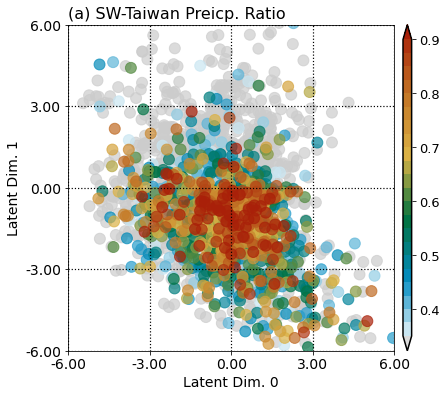

In [16]:
Plot_LS_swtwpcp(data_label='all', sep_interval=4, savefig=True)

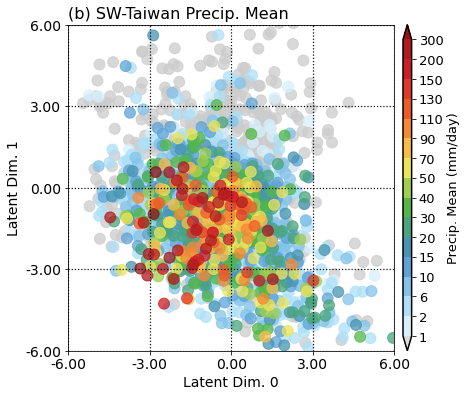

In [19]:
Plot_LS_swpcp(data_label='all', sep_interval=4, figtitle='(b) SW-Taiwan Precip. Mean', savefig=True)

## Separating the latent space into 7x7

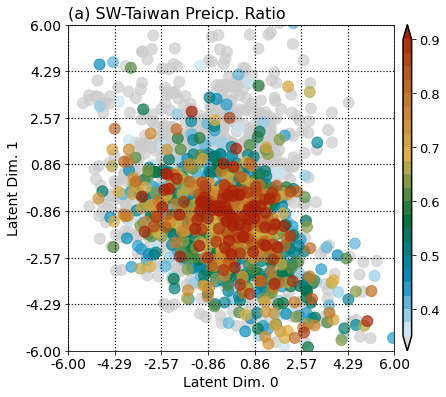

In [20]:
Plot_LS_swtwpcp(data_label='all', sep_interval=7, savefig=True)

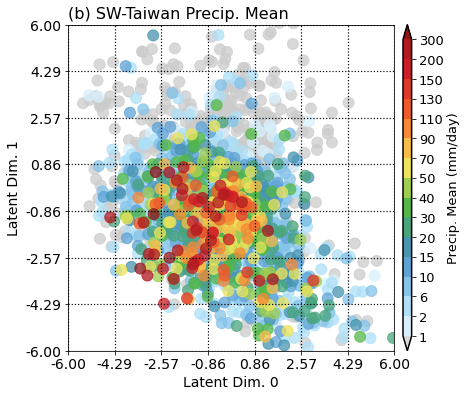

In [21]:
Plot_LS_swpcp(data_label='all', sep_interval=7, figtitle='(b) SW-Taiwan Precip. Mean', savefig=True)

# Figure: IVT colored with precip. (7x7)

In [26]:
def Plot_precip_polar(data_label:str, sep_interval:int, type_:str, figtitle:str, dotsize_ratio=1, savefig=True):
    df_up_polar['yyyymmdd'] = pd.to_datetime(df_up_polar['yyyymmdd'], format="%Y%m%d")
    # picked regimes
    regime_bnds = np.linspace(-6, 6, sep_interval+1)
    if sep_interval == 7:
        cond0       = (wtab_all['ERA5_all_lv0']>=regime_bnds[1])&(wtab_all['ERA5_all_lv0']<regime_bnds[5])
        cond1       = (wtab_all['ERA5_all_lv1']>=regime_bnds[1])&(wtab_all['ERA5_all_lv1']<regime_bnds[4])
    elif sep_interval == 4:
        raise ValueWarning("Ill-defined regimes.")
    # Type settings
    if type_ == 'fraction':
        projcolors= np.where(np.isnan(swpcp_ratio[cond0&cond1]), 0, swpcp_ratio[cond0&cond1])
        bounds_  = np.arange(0.35, 0.91, 0.025)
        color    = ['w', '#048DC3', '#02723E', '#DCB345', '#C27425', '#A92009']
        nodes    = np.linspace(0,1,len(color))
        cmap_    = colors.LinearSegmentedColormap.from_list("cmap", list(zip(nodes, color)))
        cmap_.set_under((0.8, 0.8, 0.8, 0.7))
        size_bounds = [.4, .6, .7, .8]                               # Define bounds for size categories
        tick_bounds = bounds_[2::4]
        tick_labels = [f"{i:.1f}" for i in bounds_[2::4]]
        cbar_label  = ''
    elif type_ == 'mean':
        projcolors= swpcp_all[cond0&cond1]['mean'].values
        bounds_  = np.array([1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300])
        cmap_    = cmaps.WhiteBlueGreenYellowRed.copy()
        cmap_.set_under((0.8, 0.8, 0.8, 0.7))
        size_bounds = [15, 40, 100, 150]                              # Define bounds for size categories
        tick_bounds = bounds_
        tick_labels = bounds_
        cbar_label  = '(mm/day)'
    # Size settings
    dot_sizes = np.array([80, 100, 130, 160, 190])*dotsize_ratio  # Sizes corresponding to the bounds# Map color levels to dot sizes
    sizes = np.zeros_like(projcolors, dtype=int)
    for i, (low, high) in enumerate(zip(size_bounds[:-1], size_bounds[1:])):
        sizes[(projcolors >= low) & (projcolors < high)] = dot_sizes[i+1]
    sizes[projcolors <  size_bounds[0]] = dot_sizes[0]    # For the lowest category
    sizes[projcolors >= size_bounds[-1]] = dot_sizes[-1]  # For the highest category
    
    # Figure
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection':'polar'})
    ax.grid(linestyle=':',linewidth=1, color='grey')
    util_draw_polar.draw_met_polar(ax)
    if type_ == 'fraction':
        util_draw_polar.draw_sswf_sector(axe=ax, ls=(0, (1, 1)), lc='black', alpha=0.65)
    elif type_== 'mean':
        util_draw_polar.draw_sswf_sector(axe=ax, lc='black', alpha=0.65)
    norm_    = colors.BoundaryNorm(bounds_, cmap_.N, extend='both')
    temp1    = np.argsort(projcolors)
    im = ax.scatter(df_up_polar[cond0&cond1]['IVT_theta'].iloc[temp1], df_up_polar[cond0&cond1]['IVT_r'].iloc[temp1], s=sizes[temp1], c=projcolors[temp1], alpha=0.65, cmap=cmap_, norm=norm_)
    util_draw_polar.draw_met_polar_rticks(axe=ax, rmin=0, rmax=800, 
                                    ticks=np.arange(200, 800.1, 200), ticklabels=[f"{int(i)}" for i in np.arange(200, 800.1, 200)], tick_fs=13)
    cax          = fig.add_axes([ax.get_position().x0, ax.get_position().y0-0.07, ax.get_position().width, 0.02])
    cbar         = fig.colorbar(im, orientation='horizontal', cax=cax)
    cbar.solids.set(alpha=1)
    cbar.set_ticks(ticks=tick_bounds, labels=tick_labels)
    if type_== 'fraction':
        cbar.ax.tick_params(labelsize=13)
        figname  = 'swfrac'
    elif type_=='mean':
        cbar.ax.tick_params(labelsize=13, rotation=25)
        figname  = 'swmean'
    cbar.set_label(f'{cbar_label}', fontsize=13)
    cbar.outline.set_linewidth(1.5)
    ax.set_title(f'{figtitle} ({sep_interval}x{sep_interval})', loc='left', fontsize=18)
    if savefig:
        plt.savefig(f"{polar_figpath}/all_{figname}_{sep_interval}x{sep_interval}.png", facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

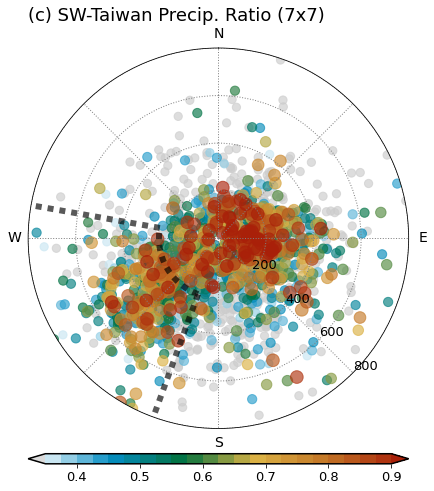

In [27]:
Plot_precip_polar(data_label='all', sep_interval=7, type_='fraction', figtitle='(c) SW-Taiwan Precip. Ratio', dotsize_ratio=0.85, savefig=True)

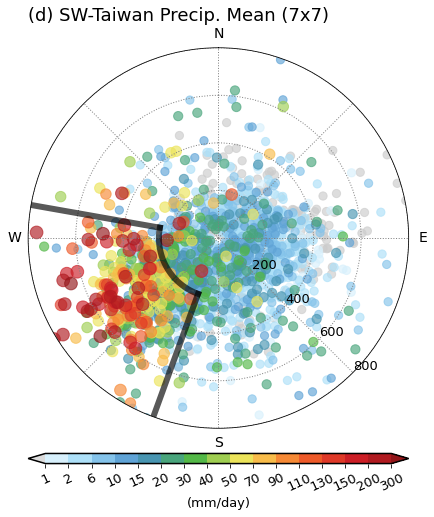

In [28]:
Plot_precip_polar(data_label='all', sep_interval=7, type_='mean', figtitle='(d) SW-Taiwan Precip. Mean', dotsize_ratio=0.85, savefig=True)

# Figure: Rain gauge composite (7x7)

## Data

In [29]:
sep_interval = 7
regime_bnds  = np.linspace(-6, 6, 7+1)

In [30]:
cond_lv0_all  = (wtab_all['ERA5_all_lv0']>=regime_bnds[1])&(wtab_all['ERA5_all_lv0']<regime_bnds[5])                  # six heavy-rainfall-promoting IVT regimes
cond_lv1_all  = (wtab_all['ERA5_all_lv1']>=regime_bnds[1])&(wtab_all['ERA5_all_lv1']<regime_bnds[4])
df_up_polar['IVT_theta'] = df_up_polar['IVT_theta'].mask(df_up_polar['IVT_theta']<0, df_up_polar['IVT_theta']+np.pi*2)
df_polar_preg = df_up_polar[cond_lv0_all&cond_lv1_all]

## Calculate composite

In [31]:
def Cal_cwa_dpcp_comp(datelist:list, pcp_filter_min=0.):
    for i, dd in enumerate(datelist):
        # Data initialize
        if i < 1:
            pcp_table = wtab_module_all.get_cwb_precip_table(dd, accumulate_daily=True)
            pcp_comp  = pcp_table['precip'].values[:, np.newaxis]
        else:
            temp = wtab_module_all.get_cwb_precip_table(dd, accumulate_daily=True)['precip'].values
            pcp_comp  = np.concatenate((pcp_comp, temp[:, np.newaxis]), axis=1)
    print(pcp_comp.shape)
    daily_max = np.nanmax(pcp_comp, axis=0)
    mask      = daily_max>pcp_filter_min
    print(pcp_comp[..., mask].shape)
    mean_pcp  = np.nanmean(pcp_comp[..., mask], axis=1)
    return pcp_table['stn_lon'], pcp_table['stn_lat'], mean_pcp

In [32]:
strong_cond    = (df_polar_preg['IVT_r']>=250)&(df_polar_preg['IVT_theta']>=np.deg2rad(200))&(df_polar_preg['IVT_theta']<=np.deg2rad(280))
dlist_preg_sswf= df_polar_preg[strong_cond]['yyyymmdd'].to_list()

In [33]:
stn_lon, stn_lat, mean_pcp_preg_sswf = Cal_cwa_dpcp_comp(datelist=dlist_preg_sswf)

(740, 650)
(740, 649)


/tmp/ipykernel_3254805/3095266240.py:14: RuntimeWarning: Mean of empty slice
  mean_pcp  = np.nanmean(pcp_comp[..., mask], axis=1)


In [34]:
dlist_preg_nosswf= df_polar_preg[~strong_cond]['yyyymmdd'].to_list()
print(len(dlist_preg_nosswf))

2060


In [35]:
stn_lon, stn_lat, mean_pcp_preg_nosswf = Cal_cwa_dpcp_comp(datelist=dlist_preg_nosswf)

(740, 2060)
(740, 2055)


/tmp/ipykernel_3254805/3095266240.py:14: RuntimeWarning: Mean of empty slice
  mean_pcp  = np.nanmean(pcp_comp[..., mask], axis=1)


## Plot composite

In [39]:
def Plot_cwb_comp_add_settings(rainfall_label:str, precip_array, sw_rect=False, figtitle=False, savefig=False):
    if rainfall_label=='strong':
        bounds    = np.array([2, 5, 10, 15, 25, 40, 50, 70, 90])
        alpha     = 0.8
        figname   = 'mysswf'
    elif rainfall_label=='weak':
        bounds    = np.array([2, 5, 10, 15, 25])
        alpha     = 0.85
        figname   = 'nosswf'
    # Figure initialize
    fig = plt.figure(figsize=(4, 8))
    gs  = GridSpec(1, 1, figure=fig)
    ## Plot:
    ax1   = plottools.Axe_map(fig, gs[0], xlim_=[119.95, 122.05], ylim_=[21.85, 25.5], 
                              xloc_=np.arange(120, 122.1, 1), yloc_=np.arange(22, 25.1, 1))
    plottools.Plot_vvm_map(ax1, c['dark grey'], 1.5)  # coastline
    temp = np.argsort(precip_array)
    # imcwb = plottools.Plot_twcwb_pcp(ax1, 
    #                                  dict_cwa_pcp_comp['stn_lon'][temp], 
    #                                  dict_cwa_pcp_comp['stn_lat'][temp], 
    #                                  precip_array[temp], s=75, alpha=alpha, precip_bounds=bounds)
    imcwb = plottools.Plot_twcwb_pcp(ax1, 
                                     stn_lon[temp], 
                                     stn_lat[temp], 
                                     precip_array[temp], s=75, alpha=alpha, precip_bounds=bounds)
    cax  = fig.add_axes([ax1.get_position().x1+0.06, ax1.get_position().y0, 0.03, ax1.get_position().height])
    cbar = fig.colorbar(imcwb, orientation='vertical', cax=cax)
    cbar.solids.set(alpha=1)  # Default: set cbar to full color (w/out tranparency)
    cbar.set_ticks(ticks=bounds, labels=[int(i) for i in bounds])
    cbar.set_label('mm/day', fontsize=16)
    cbar.ax.tick_params(labelsize=13)
    cbar.outline.set_linewidth(1.5)

    topo_bounds= np.arange(0, 3500.1, 500)
    imtopoh    = plottools.Plot_vvm_topo(ax1, c['dark grey'], 0.5)
    cax  = fig.add_axes([ax1.get_position().x0,ax1.get_position().y0-0.06, ax1.get_position().width, 0.015])
    cbar = fig.colorbar(imtopoh, orientation='horizontal', cax=cax, extend='max')
    cbar.set_ticks(ticks=topo_bounds, labels=[f"{i/1e3:.1f}" for i in topo_bounds])
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('Topography Height (km)', fontsize=16)
    cbar.outline.set_linewidth(1.5)
    
    if sw_rect:
        rect = patches.Rectangle((120, 21.9), 1, 1.6, fc="none", ec=c['black'], linewidth=2, zorder=50, label='southwestern')
        ax1.add_artist(rect)
        ax1.legend(handles=[rect], fontsize=13, loc='upper left')

    ax1.set_xticklabels([f'{int(i)}\N{DEGREE SIGN} E' for i in np.arange(120, 122.1, 1)], fontsize=16)
    ax1.set_yticklabels([f'{int(i)}\N{DEGREE SIGN} N' for i in np.arange(22, 25.1, 1)], fontsize=16)
    if figtitle:
        ax1.set_title(f'{figtitle}', loc='left', fontsize=20)
    else:
        ax1.set_title('CWA precipitation', fontsize=16)
        fig.suptitle(x=0.5, y=0.91, t='Composite [Picked Reg.+SSWF]', fontsize=18, fontweight='bold')
    if savefig:
        plt.savefig(f"{obs_figpath}/12reg_{figname}_7x7.png", facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

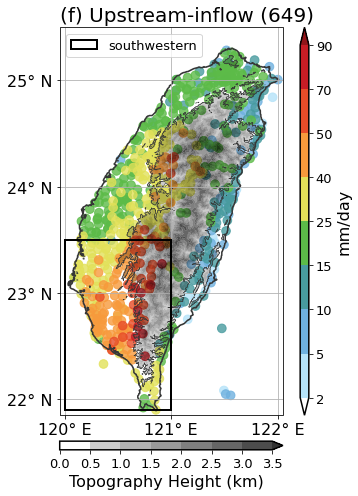

In [45]:
Plot_cwb_comp_add_settings(rainfall_label='strong', precip_array=mean_pcp_preg_sswf, sw_rect=True, figtitle='(f) Upstream-inflow (649)', savefig=True)

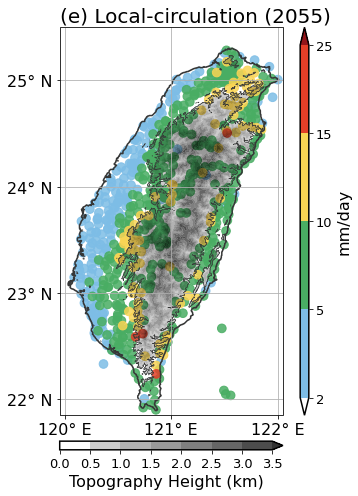

In [46]:
Plot_cwb_comp_add_settings(rainfall_label='weak', precip_array=mean_pcp_preg_nosswf, figtitle='(e) Local-circulation (2055)', savefig=True)